# **Facial Emotion Recognition using CNN**

## **Introduction**

DeepFER: Facial Emotion Recognition Using Deep Learning is a project aimed at developing a robust and efficient system for automatically identifying human emotions from facial expressions. By leveraging advanced deep learning techniques, particularly Convolutional Neural Networks (CNNs) and Transfer Learning, DeepFER is designed to classify emotions such as happiness, sadness, anger, surprise, fear, disgust, and neutrality from facial images.

Facial emotion recognition plays a crucial role in numerous applications, including human-computer interaction, customer service, and mental health monitoring. Traditional approaches relied on handcrafted features and rule-based systems, which often struggled to generalize across diverse faces and real-world conditions. DeepFER addresses these challenges by using deep neural networks to automatically learn hierarchical features from raw image data, achieving high accuracy and real-time performance.

The ultimate goal of DeepFER is to create a versatile and practical tool that allows machines to understand and respond to human emotions, bridging the gap between artificial intelligence and empathetic human-machine interactions.

---

## **Dataset Overview**

DeepFER utilizes the **FER-2013 dataset**, a widely used benchmark for facial emotion recognition. Key characteristics of the dataset are:

* **Image Format:** 48x48 pixel grayscale images
* **Data Alignment:** Faces are automatically registered to be centered and occupy a similar area within the image
* **Dataset Size:**

  * Total: 24,400 images
  * Training set: 22,968 images
  * Public test set: 1,432 images
    
* **Emotion Classes:**

  1. Angry
  2. Disgust
  3. Fear
  4. Happy
  5. Sad
  6. Surprise
  7. Neutral
* **Data Characteristics:**

  * Grayscale images to simplify computational requirements
  * Poses are consistent to focus on facial expressions
  * Captures both posed and spontaneous expressions for better generalization

The FER-2013 dataset provides a solid foundation for training and evaluating the DeepFER model, allowing for accurate and real-time classification of seven distinct human emotions.




## **Installing Required Libraries**

In [2]:
# Upgrade pip (optional but recommended)
# !pip install --upgrade pip

# Install required libraries
!pip install tensorflow keras opencv-python-headless numpy pandas scikit-learn matplotlib seaborn


## Verify Installations

In [3]:
import tensorflow as tf
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)
print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Seaborn version:", sns.__version__)

TensorFlow version: 2.21.0
OpenCV version: 4.13.0
NumPy version: 2.1.3
Pandas version: 2.2.3
Seaborn version: 0.13.2


In [5]:
import numpy as np             # Numerical operations
import pandas as pd            # Data manipulation / CSV I/O
import os                      # File system operations
import matplotlib.pyplot as plt  # Visualization
import seaborn as sns          # Enhanced visualization
import tensorflow as tf        # Deep learning framework
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Adamax
import cv2                     # Image processing
from tensorflow.keras.applications import VGG16, InceptionResNetV2  # For transfer learning
from keras import regularizers                                     # Optional: add weight regularization
from keras.preprocessing import image                               # Alternative to tf.keras.preprocessing

## **Data Ingestion**

In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

In [6]:
train_dir = "C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_5_CNN/DeepFER_datasets/train"
test_dir = "C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_5_CNN/DeepFER_datasets/validation"

## **Displaying one image for each emotion in train set**

In [7]:
import os
class_names = os.listdir("C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_5_CNN/DeepFER_datasets/train")
print(class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


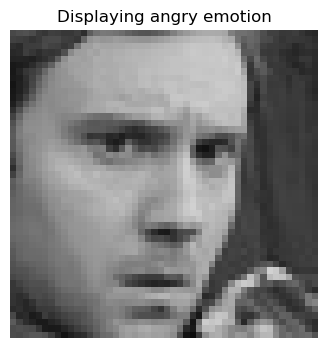

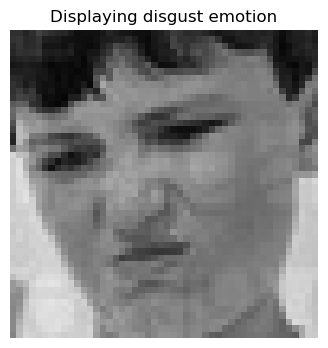

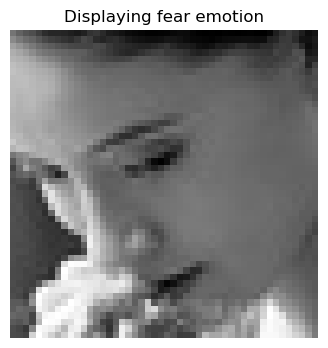

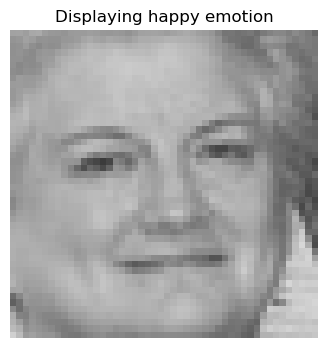

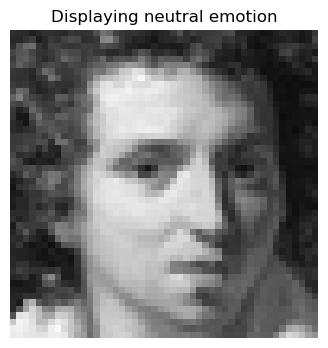

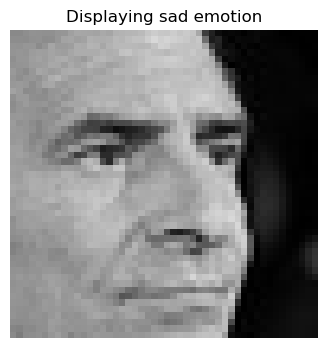

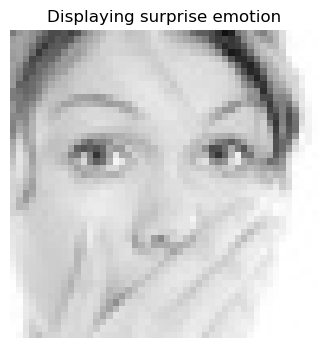

In [6]:
import glob

dataset_path = r"C:\Users\aimee\OneDrive\Documents\ML_Projects\Spl_Mod_5_CNN\DeepFER_datasets"

# Get all emotion folders inside train
emotion_folders = glob.glob(os.path.join(dataset_path, "train", "*"))

for folder in emotion_folders:
    emotion = os.path.basename(folder)

    # Get first image from the folder
    image_files = glob.glob(os.path.join(folder, "*"))

    if len(image_files) > 0:
        img = cv2.imread(image_files[0])

        # Convert BGR to RGB for correct display
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.title(f"Displaying {emotion} emotion")
        plt.axis("off")
        plt.show()

## **Data Augmentation & Generators for DeepFER**

In [9]:
# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalize pixel values
    rotation_range=30,           # Randomly rotate images
    width_shift_range=0.1,       # Horizontal shift
    height_shift_range=0.1,      # Vertical shift
    shear_range=0.1,             # Shear transformation
    zoom_range=0.1,              # Zoom in/out
    horizontal_flip=True,        # Random horizontal flip
    fill_mode='nearest'          # Fill missing pixels
)

In [10]:
# Validation data generator (no augmentation, only rescale)
val_datagen = ImageDataGenerator(rescale=1./255)

In [11]:
# Flow Images from Directory

batch_size = 64
target_size = (48, 48)  # FER-2013 standard size
color_mode = "grayscale" # FER-2013 is grayscale
class_mode = "categorical"  # Multi-class classification

# Training generator
train_generator = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=target_size,
    batch_size=batch_size,
    color_mode=color_mode,
    class_mode=class_mode,
    shuffle=True
)

# Validation generator
val_generator = val_datagen.flow_from_directory(
    directory=test_dir,
    target_size=target_size,
    batch_size=batch_size,
    color_mode=color_mode,
    class_mode=class_mode,
    shuffle=False
)

Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.


In [12]:
# Class Indices and Labels

class_indices = train_generator.class_indices
labels = {v: k for k, v in class_indices.items()}  # Reverse mapping

print("Class Indices:", class_indices)
print("Labels Mapping:", labels)

Class Indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Labels Mapping: {0: 'angry', 1: 'disgust', 2: 'fear', 3: 'happy', 4: 'neutral', 5: 'sad', 6: 'surprise'}


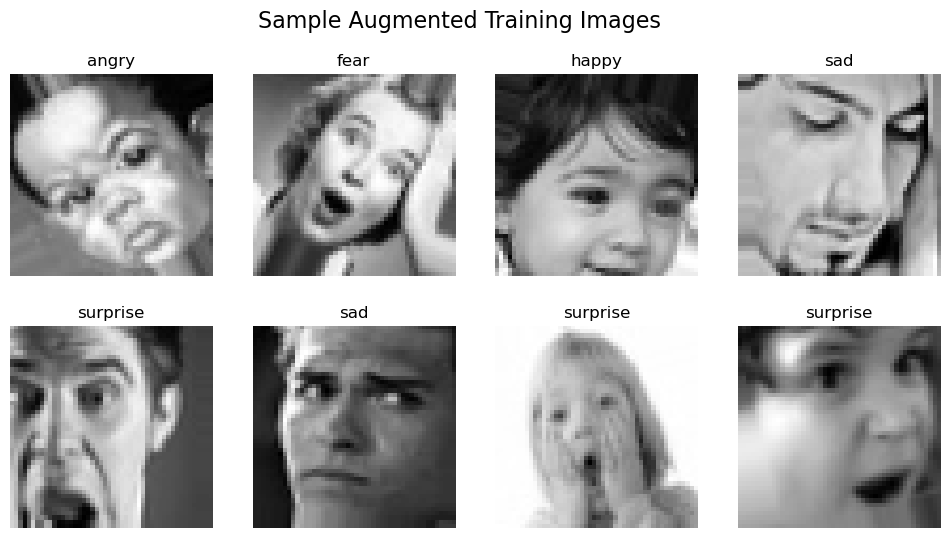

In [13]:
# Display Some Augmented Images

x_batch, y_batch = next(train_generator)  # Get one batch of training images

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(x_batch[i].reshape(48,48), cmap='gray')
    plt.title(labels[y_batch[i].argmax()])
    plt.axis('off')
plt.suptitle("Sample Augmented Training Images", fontsize=16)
plt.show()

In [14]:
# Input Shape for Model

img_shape = train_generator.image_shape
print("Input Shape for Model:", img_shape)

Input Shape for Model: (48, 48, 1)


## **CNN Model Custom Architecture**

To develop the CNN architecture, we will begin by defining the input layer and the number of filters in the first convolutional layer. Then, we will add additional convolutional layers with increasing numbers of filters, followed by max-pooling layers to reduce the spatial dimensions of the feature maps. After the convolutional layers, we will add fully connected layers with ReLU activation to classify the emotions.

We will experiment with different numbers of convolutional layers, filter sizes, and fully connected layers to optimize the model performance. Additionally, we will use techniques such as dropout and batch normalization to prevent overfitting and improve the generalization capability of the model.


In [15]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Input Layer
inputs = Input(shape=(48, 48, 1), name='input_layer')

# ----------------------------
# Convolutional Block 1
# ----------------------------
x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2,2))(x)
x = Dropout(0.25)(x)

# ----------------------------
# Convolutional Block 2
# ----------------------------
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2,2))(x)
x = Dropout(0.25)(x)

# ----------------------------
# Convolutional Block 3
# ----------------------------
x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)

x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2,2))(x)
x = Dropout(0.25)(x)

# ----------------------------
# Fully Connected Layer
# ----------------------------
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

# Output Layer: 7 classes
outputs = Dense(7, activation='softmax')(x)

# Define Model
model = Model(inputs=inputs, outputs=outputs)

# Compile Model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Model Summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,02

 Total params: 3,491,335 (13.32 MB)

 Trainable params: 3,489,095 (13.31 MB)

 Non-trainable params: 2,240 (8.75 KB)

In [16]:
epochs = 42
batch_size = 64

## **CNN Model Training for DeepFER**

In [17]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

# -----------------------------------------
# Learning Rate Scheduler
# Automatically reduce LR when val accuracy stops improving
# -----------------------------------------
lr_scheduler = ReduceLROnPlateau(
    monitor='val_accuracy',
    patience=8,          # Wait for 8 epochs without improvement
    factor=0.8,          # Reduce LR by 20%
    min_lr=1e-7,         # Minimum allowed LR
    min_delta=1e-7,      # Minimum improvement threshold
    verbose=1
)

# -----------------------------------------
# Model Checkpoint
# Saves only the version of the model with the best validation accuracy
# -----------------------------------------
checkpoint_callback = ModelCheckpoint(
    filepath='best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# -----------------------------------------
# Combine Callbacks
# -----------------------------------------
callbacks_list = [lr_scheduler, checkpoint_callback]


In [18]:
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,  
    callbacks=callbacks_list,
    verbose=1
)


Epoch 1/42
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2077 - loss: 2.3101  
Epoch 1: val_accuracy improved from None to 0.20393, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 502s 1s/step - accuracy: 0.2415 - loss: 2.0717 - val_accuracy: 0.2039 - val_loss: 3.3059 - learning_rate: 0.0010
Epoch 2/42
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3121 - loss: 1.7749  
Epoch 2: val_accuracy improved from 0.20393 to 0.47056, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 481s 1s/step - accuracy: 0.3413 - loss: 1.6927 - val_accuracy: 0.4706 - val_loss: 1.3851 - learning_rate: 0.0010
Epoch 3/42
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4264 - loss: 1.4887      
Epoch 3: val_accuracy improved from 0.47056 to 0.51514, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 479s 1s/step - accuracy: 0.4404 - loss: 1.4513 - val_accuracy: 0.5151 - val_loss: 1.3242 - learning_rate: 0.0010
Epoch 4/42
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 990ms/step - accuracy: 0.4813 - loss: 1.3562   
Epoch 4: val_accuracy did not improve from 0.51514
451/451 ━━━━━━━━━━━━━━━━━━━━ 473s 1s/step - accuracy: 0.4902 - loss: 1.3334 - val_accuracy: 0.5136 - val_loss: 1.2852 - learning_rate: 0.0010
Epoch 5/42
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 940ms/step - accuracy: 0.5150 - loss: 1.2718   
Epoch 5: val_accuracy improved from 0.51514 to 0.52080, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 448s 992ms/step - accuracy: 0.5201 - loss: 1.2620 - val_accuracy: 0.5208 - val_loss: 1.3276 - learning_rate: 0.0010
Epoch 6/42
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 914ms/step - accuracy: 0.5345 - loss: 1.2230  
Epoch 6: val_accuracy improved from 0.52080 to 0.56850, saving model to best_model.h5


...


Epoch 25: finished saving model to best_model.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 384s 851ms/step - accuracy: 0.6436 - loss: 0.9513 - val_accuracy: 0.6558 - val_loss: 0.9452 - learning_rate: 0.0010
Epoch 26/42
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 806ms/step - accuracy: 0.6438 - loss: 0.9461  
Epoch 26: val_accuracy improved from 0.65582 to 0.65950, saving model to best_model.h5



Epoch 26: finished saving model to best_model.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 383s 850ms/step - accuracy: 0.6409 - loss: 0.9495 - val_accuracy: 0.6595 - val_loss: 0.9363 - learning_rate: 0.0010
Epoch 27/42
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 805ms/step - accuracy: 0.6550 - loss: 0.9281  
Epoch 27: val_accuracy improved from 0.65950 to 0.66318, saving model to best_model.h5



Epoch 27: finished saving model to best_model.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 383s 849ms/step - accuracy: 0.6490 - loss: 0.9376 - val_accuracy: 0.6632 - val_loss: 0.9332 - learning_rate: 0.0010
Epoch 28/42
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 814ms/step - accuracy: 0.6547 - loss: 0.9285  
Epoch 28: val_accuracy did not improve from 0.66318
451/451 ━━━━━━━━━━━━━━━━━━━━ 388s 861ms/step - accuracy: 0.6483 - loss: 0.9358 - val_accuracy: 0.6216 - val_loss: 1.0251 - learning_rate: 0.0010
Epoch 29/42
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 821ms/step - accuracy: 0.6574 - loss: 0.9168  
Epoch 29: val_accuracy improved from 0.66318 to 0.66544, saving model to best_model.h5



Epoch 29: finished saving model to best_model.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 390s 865ms/step - accuracy: 0.6582 - loss: 0.9190 - val_accuracy: 0.6654 - val_loss: 0.9261 - learning_rate: 0.0010
Epoch 30/42
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 814ms/step - accuracy: 0.6648 - loss: 0.9077  
Epoch 30: val_accuracy did not improve from 0.66544
451/451 ━━━━━━━━━━━━━━━━━━━━ 387s 858ms/step - accuracy: 0.6609 - loss: 0.9157 - val_accuracy: 0.6521 - val_loss: 0.9710 - learning_rate: 0.0010
Epoch 31/42
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 820ms/step - accuracy: 0.6565 - loss: 0.9081  
Epoch 31: val_accuracy did not improve from 0.66544
451/451 ━━━━━━━━━━━━━━━━━━━━ 391s 866ms/step - accuracy: 0.6571 - loss: 0.9146 - val_accuracy: 0.6311 - val_loss: 1.0291 - learning_rate: 0.0010
Epoch 32/42
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 816ms/step - accuracy: 0.6626 - loss: 0.9063  
Epoch 32: val_accuracy did not improve from 0.66544
451/451 ━━━━━━━━━━━━━━━━━━━━ 388s 859ms/step - accuracy: 0.6578 - loss: 0.9159 - val_a


Epoch 41: finished saving model to best_model.h5
451/451 ━━━━━━━━━━━━━━━━━━━━ 393s 871ms/step - accuracy: 0.6837 - loss: 0.8425 - val_accuracy: 0.6680 - val_loss: 0.9233 - learning_rate: 8.0000e-04
Epoch 42/42
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 825ms/step - accuracy: 0.6835 - loss: 0.8373  
Epoch 42: val_accuracy did not improve from 0.66799
451/451 ━━━━━━━━━━━━━━━━━━━━ 392s 870ms/step - accuracy: 0.6797 - loss: 0.8511 - val_accuracy: 0.6487 - val_loss: 0.9820 - learning_rate: 8.0000e-04


## **Model Evaluation Section**

## **Evaluate the model on validation data**

In [20]:
# Evaluate performance on validation set
val_loss, val_accuracy = model.evaluate(val_generator, verbose=1)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Loss: {val_loss:.4f}")


111/111 ━━━━━━━━━━━━━━━━━━━━ 18s 165ms/step - accuracy: 0.6487 - loss: 0.9820
Validation Accuracy: 0.6487
Validation Loss: 0.9820


## **Plot Accuracy & Loss Curves**

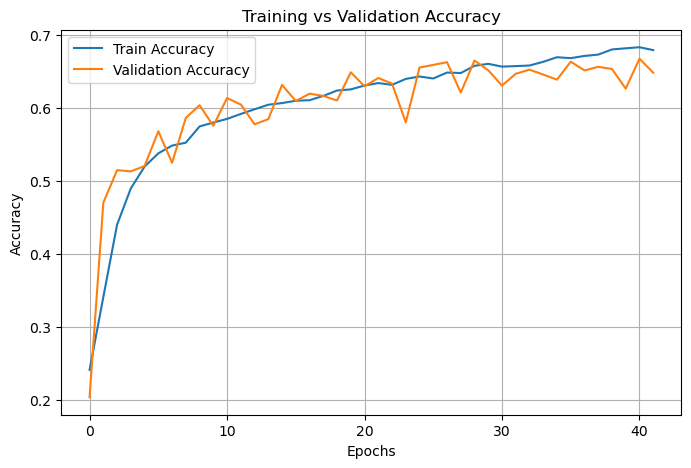

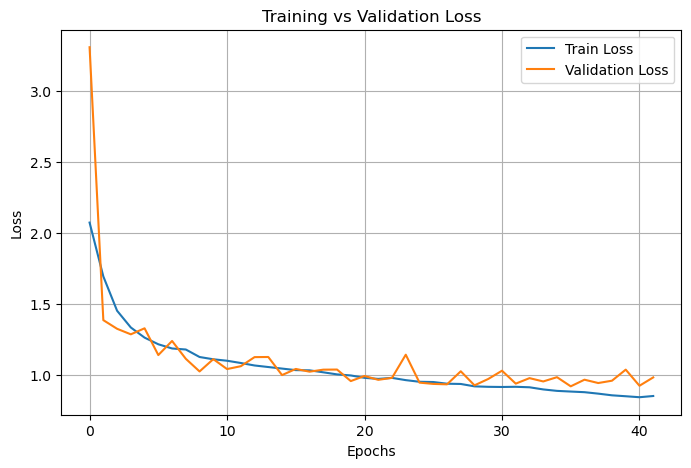

In [22]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

# Loss Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

## **Classification Report**

In [23]:
from sklearn.metrics import classification_report
import numpy as np

# True labels from generator
true_labels = val_generator.classes

# Predictions
pred_probs = model.predict(val_generator)
pred_labels = np.argmax(pred_probs, axis=1)

# Class label mapping
class_names = list(val_generator.class_indices.keys())

print(classification_report(true_labels, pred_labels, target_names=class_names))


111/111 ━━━━━━━━━━━━━━━━━━━━ 19s 170ms/step
              precision    recall  f1-score   support

       angry       0.61      0.49      0.55       960
     disgust       0.84      0.48      0.61       111
        fear       0.56      0.42      0.48      1018
       happy       0.89      0.85      0.87      1825
     neutral       0.48      0.79      0.60      1216
         sad       0.54      0.47      0.50      1139
    surprise       0.81      0.74      0.77       797

    accuracy                           0.65      7066
   macro avg       0.68      0.61      0.62      7066
weighted avg       0.67      0.65      0.65      7066



## **Confusion Matrix**


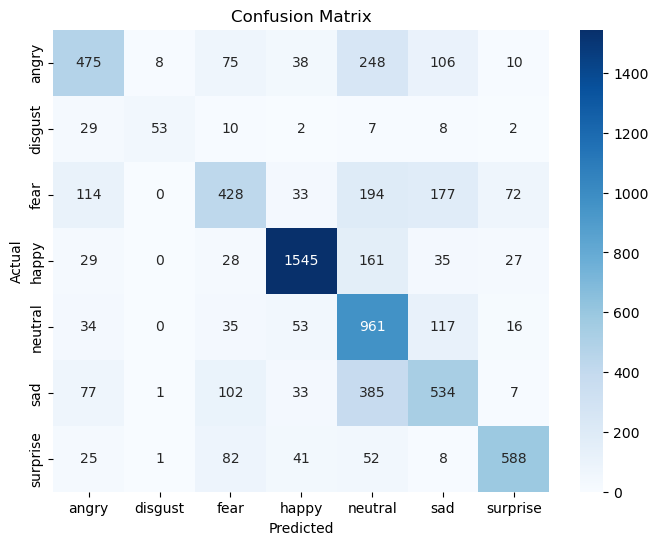

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Testing Random Validation Data

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


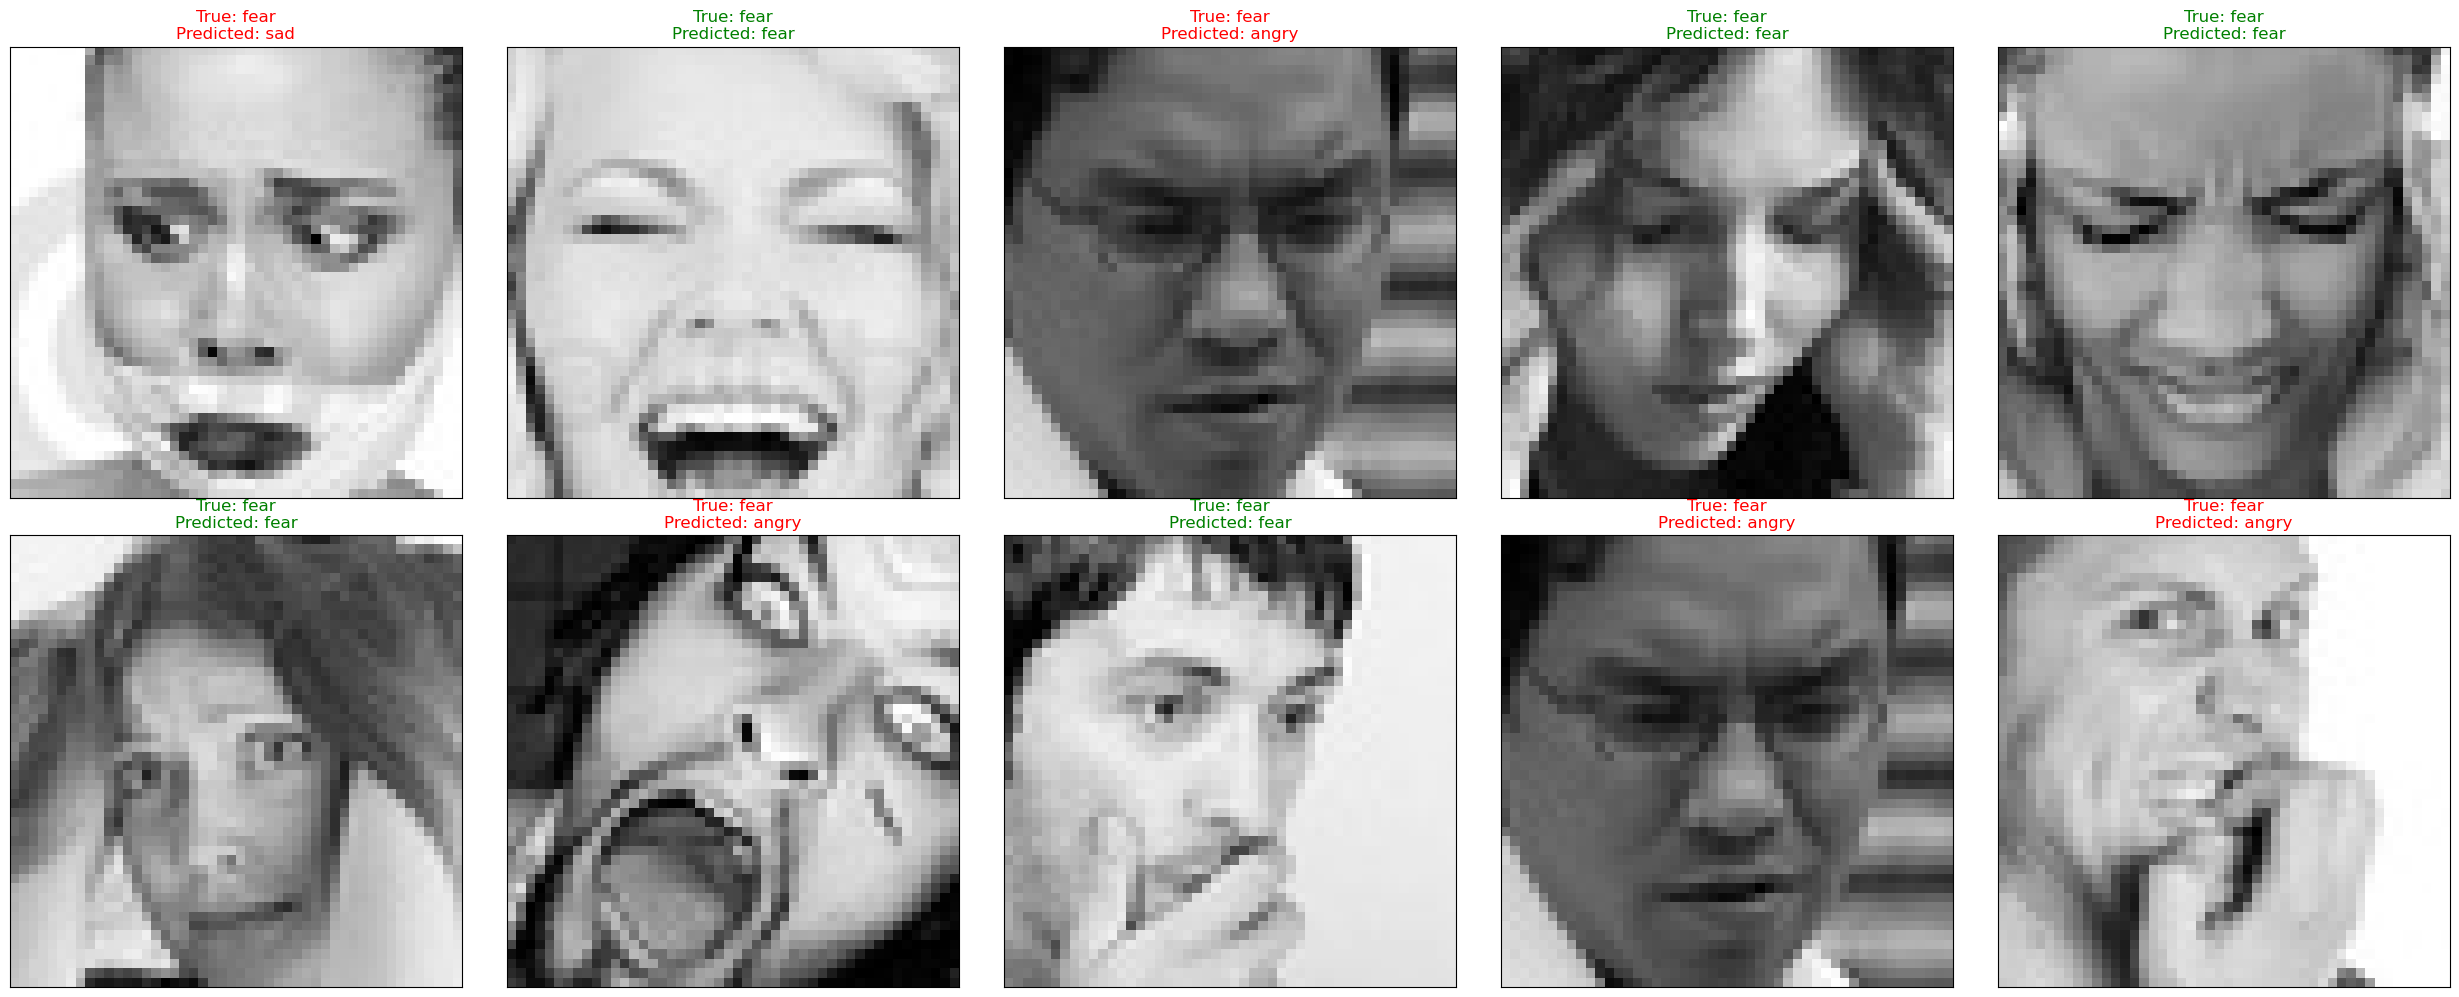

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Define the emotion labels
labels = {0: 'angry', 1: 'disgust', 2: 'fear', 3: 'happy', 4: 'neutral', 5: 'sad', 6: 'surprise'}



# Get the batch size from the validation generator
batch_size = val_generator.batch_size

# Generate random batch and image indices
random_batch = np.random.randint(0, len(val_generator) - 1)
random_img_indices = np.random.randint(0, batch_size, 10)

# Create a plot
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(25, 10), subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    # Get a random image and its true label from the validation data
    random_img = val_generator[random_batch][0][random_img_indices[i]]
    random_img_label = np.argmax(val_generator[random_batch][1][random_img_indices[i]])
    print(type(random_img))
    # Predict the label using the model
    model_prediction = np.argmax(model.predict(tf.expand_dims(random_img, axis=0), verbose=0))

    # Display the image
    ax.imshow(random_img.squeeze(), cmap='gray')

    # Determine the color of the title (green if correct, red if incorrect)
    if labels[random_img_label] == labels[model_prediction]:
        color = "green"
    else:
        color = "red"

    # Set the title of the subplot
    ax.set_title(f"True: {labels[random_img_label]}\nPredicted: {labels[model_prediction]}", color=color)

# Show the plot
plt.tight_layout()
plt.show()


## Saving the Model

In [27]:
# Save the entire model
model.save('cnn_model_new_.h5')

In [8]:
import cv2
face_haar_cascade = cv2.CascadeClassifier('C:/Users/aimee/OneDrive/Data Science MSc/AlmaBetter MSc Data Science/Capstone Projects/Spl_Mod_5_CNN/My_project/Real_Time/haarcascade_frontalface_default.xml')